In [2]:
import pickle as pkl
import pandas as pd
import numpy as np
from pathlib import Path

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from src import util_analysis 
from scipy import stats 


In [3]:
### Import pre-formated data 

results_dir = Path('final_results_dir')

# diotic SWC 
diotic_results = pd.read_pickle(results_dir / "df_for_stats_and_summary_2024_SWC_diotic_conditions_humans_N-195_models_v10_w_control_archs.pdpkl")

# Popham SWC
popham_results = pd.read_pickle(results_dir / "df_for_stats_2024_SWC_popham_conditions_humans_N-90_models_v10_w_control_archs.pdpkl")
popham_results.loc[popham_results.group.str.contains("Human"), 'model'] = popham_results.loc[popham_results.group.str.contains("Human"), 'group']
popham_results['snr'] = 0 # add snr column to match diotic_results
popham_conds_to_keep = ['Harmonic_target_Harmonic_distractor',
                        'Harmonic_target_No Distractor_distractor',
                        'Inharmonic_target_Inharmonic_distractor',
                        'Inharmonic_target_No Distractor_distractor',
                        'Whispered_target_No Distractor_distractor',
                        'Whispered_target_Whispered_distractor']

popham_results = popham_results[popham_results['background_condition'].isin(popham_conds_to_keep)].reset_index(drop=True)

# threshold results 
threshold_results = pd.read_pickle(results_dir / "df_for_stats_and_summary_2024_thresholds_humans_N-33_models_v10_w_control_archs.pdpkl")
threshold_results['background_condition'] = threshold_results['azim_delta'].astype('str') + ' azim delta ' + threshold_results['elev_delta'].astype('str') + ' elev delta' 

# Spotlight results 
spotlight_results = pd.read_pickle(results_dir / "df_for_stats_and_summary_2024_spotlight_humans_N-28_models_v10_w_control_archs.pdpkl")
spotlight_results['snr'] = 0 
spotlight_results['background_condition'] = spotlight_results['target_azim'].astype('str') + ' target azim ' + spotlight_results['azim_delta'].astype('str') + ' azim delta'

In [4]:
combined_results = pd.concat([diotic_results, popham_results, threshold_results, spotlight_results], axis=0)
## update model names for comparison 

combined_results.loc[combined_results['model'].str.contains("early"), 'model'] = 'Early-only'
combined_results.loc[combined_results['model'].str.contains("late"), 'model'] = 'Late-only'
combined_results.loc[combined_results['model'].str.contains("control"), 'model'] = 'Baseline CNN'

In [5]:
combined_results.model.unique()

array(['Human (N=195)', 'word_task_v10_4MGB_ln_first_arch_1',
       'word_task_v10_4MGB_ln_first_arch_10',
       'word_task_v10_4MGB_ln_first_arch_12',
       'word_task_v10_4MGB_ln_first_arch_2',
       'word_task_v10_4MGB_ln_first_arch_4',
       'word_task_v10_4MGB_ln_first_arch_6',
       'word_task_v10_4MGB_ln_first_arch_7',
       'word_task_v10_4MGB_ln_first_arch_8',
       'word_task_v10_4MGB_ln_first_arch_9',
       'word_task_v10_main_feature_gain_config', 'Early-only',
       'Late-only', 'Baseline CNN', 'Humans (N = 90)', 'Human (N=33)',
       'Humans (N=28)'], dtype=object)

In [6]:
combined_results['snr_condition_str'] = combined_results['snr'].astype(str) + ' dB ' + combined_results['background_condition']
human_results = combined_results[combined_results.group.str.contains('Human')]
human_results = human_results.sort_values(['snr', 'background_condition'])

model_list = [model for model in combined_results.model.unique() if 'Human' not in model]


model_sim_records = []

for ix, model in enumerate(model_list):
    # if model == 'Feature-gain Model':
    #     fba_to_plot = combined_results[combined_results.group.str.contains('Feature')].groupby(['snr', 'background_condition']).agg({'accuracy': ['mean', 'sem'], 'confusions':['mean', 'sem']}).reset_index()
    #     fba_to_plot.columns = ['snr', 'background_condition', 'accuracy', 'acc_sem', 'confusions', 'conf_sem']
    #     fba_to_plot['snr_condition_str'] = fba_to_plot['snr'].astype(str) + ' dB ' + fba_to_plot['background_condition']

    #     fba_to_plot['group'] = 'Feature-gain model'
    #     model_results = fba_to_plot.sort_values(['snr', 'background_condition'])
    # else:
    model_results = combined_results[combined_results.model == model]
    model_results = model_results.sort_values(['snr', 'background_condition'])

    # get missing snr x background conditions 
    # model_conds = model_results.snr_condition_str.unique()
    # human_conds = human_results.snr_condition_str.unique()
    # conds_to_keep = human_conds[np.isin(human_conds, model_conds)]

    # human_to_plot = human_results[human_results.snr_condition_str.isin(conds_to_keep)].copy()
    # model_to_plot = model_results[model_results.snr_condition_str.isin(conds_to_keep)].copy()
    


    ## Add stats 
    r, p = stats.pearsonr(human_results.accuracy,  model_results.accuracy)
    # spearman_brown_r = r / np.sqrt(main_model_rho_acc)
    acc_r = r ** 2 
    # add to dict 
    acc_rmse = np.sqrt(np.mean((human_results.accuracy.values - model_results.accuracy.values)**2))

    # conf errors
    r, p = stats.pearsonr(human_results.confusions, model_results.confusions)
    conf_r = r ** 2
    conf_rmse = np.sqrt(np.mean((human_results.confusions.values - model_results.confusions.values)**2))

    record = {'model': model, 'acc_r': acc_r, 'acc_rmse': acc_rmse, 'conf_r': conf_r, 'conf_rmse': conf_rmse}
    model_sim_records.append(record)


In [7]:
model_sim_df = pd.DataFrame.from_records(model_sim_records)

In [8]:
model_sim_df

,model,acc_r,acc_rmse,conf_r,conf_rmse
0,word_task_v10_4MGB_ln_first_arch_1,0.910322,0.125459,0.831730,0.057505
1,word_task_v10_4MGB_ln_first_arch_10,0.896985,0.157540,0.831113,0.046064
2,word_task_v10_4MGB_ln_first_arch_12,0.908346,0.147658,0.829767,0.044312
3,word_task_v10_4MGB_ln_first_arch_2,0.918620,0.099471,0.821823,0.058137
4,word_task_v10_4MGB_ln_first_arch_4,0.898365,0.135593,0.806666,0.056456
5,word_task_v10_4MGB_ln_first_arch_6,0.911709,0.117374,0.825873,0.057191
6,word_task_v10_4MGB_ln_first_arch_7,0.912677,0.090980,0.816272,0.062664
7,word_task_v10_4MGB_ln_first_arch_8,0.891507,0.122881,0.808080,0.054674
8,word_task_v10_4MGB_ln_first_arch_9,0.901948,0.118117,0.826880,0.063558
9,word_task_v10_main_feature_gain_config,0.927539,0.092704,0.822553,0.049327


In [9]:
# sign test
# from statsmodels.stats.descriptivestats import sign_test

def sign_test(x, mu0):
    n = len(x)
    n_pos = np.sum(x > mu0)
    n_neg = np.sum(x < mu0)
    effect_m = (n_pos - n_neg) / 2 
    p = stats.binomtest(min(n_pos, n_neg), n, p=0.5).pvalue
    return effect_m, p

# run sign test per alternate model 
fba_model_r_acc_dist = model_sim_df.loc[model_sim_df.model.str.contains("main|arch"), "acc_r"].values
fba_model_r_conf_dist = model_sim_df.loc[model_sim_df.model.str.contains("main|arch"), "conf_r"].values
for model in ["Early-only", "Late-only", "Baseline CNN"]:
    y_acc = model_sim_df.loc[model_sim_df.model == model, "acc_r"].values
    stats_result = sign_test(fba_model_r_acc_dist, mu0=y_acc)
    print(f"Feature-gain v {model}, Pearson's r^2 accuracy sign test stat={stats_result[0]} p={stats_result[1]:.5f}")
    y_conf = model_sim_df.loc[model_sim_df.model == model, "conf_r"].values
    stats_result = sign_test(fba_model_r_conf_dist, mu0=y_conf)
    print(f"Feature-gain v {model}, Pearson's r^2 confusions sign test stat={stats_result[0]} p={stats_result[1]:.5f}")
    print("")   

# fba_model_r_acc_dist = model_sim_df.loc[model_sim_df.model.str.contains("main|arch"), "acc_rmse"].values
# for model in ["Early-only", "Late-only", "Baseline CNN"]:
#     y = model_sim_df.loc[model_sim_df.model == model, "acc_rmse"].values
#     stats_result = sign_test(fba_model_r_acc_dist, mu0=y)
#     print(f"Feature-gain v  {model}, RMSE similarity sign test p={stats_result:.5f}")

fba_model_r_acc_dist = model_sim_df.loc[model_sim_df.model.str.contains("main|arch"), "acc_rmse"].values
fba_model_r_conf_dist = model_sim_df.loc[model_sim_df.model.str.contains("main|arch"), "conf_rmse"].values
for model in ["Early-only", "Late-only", "Baseline CNN"]:
    y_acc = model_sim_df.loc[model_sim_df.model == model, "acc_rmse"].values
    stats_result = sign_test(fba_model_r_acc_dist, mu0=y_acc)
    print(f"Feature-gain v {model}, RMSE accuracy sign test stat={stats_result[0]} p={stats_result[1]:.5f}")
    y_conf = model_sim_df.loc[model_sim_df.model == model, "conf_rmse"].values
    stats_result = sign_test(fba_model_r_conf_dist, mu0=y_conf)
    print(f"Feature-gain v {model}, RMSE confusions sign test stat={stats_result[0]} p={stats_result[1]:.5f}")
    print("")   


Feature-gain v Early-only, Pearson's r^2 accuracy sign test stat=5.0 p=0.00195
Feature-gain v Early-only, Pearson's r^2 confusions sign test stat=-5.0 p=0.00195

Feature-gain v Late-only, Pearson's r^2 accuracy sign test stat=5.0 p=0.00195
Feature-gain v Late-only, Pearson's r^2 confusions sign test stat=5.0 p=0.00195

Feature-gain v Baseline CNN, Pearson's r^2 accuracy sign test stat=5.0 p=0.00195
Feature-gain v Baseline CNN, Pearson's r^2 confusions sign test stat=2.0 p=0.34375

Feature-gain v Early-only, RMSE accuracy sign test stat=-5.0 p=0.00195
Feature-gain v Early-only, RMSE confusions sign test stat=5.0 p=0.00195

Feature-gain v Late-only, RMSE accuracy sign test stat=-5.0 p=0.00195
Feature-gain v Late-only, RMSE confusions sign test stat=-5.0 p=0.00195

Feature-gain v Baseline CNN, RMSE accuracy sign test stat=-5.0 p=0.00195
Feature-gain v Baseline CNN, RMSE confusions sign test stat=4.0 p=0.02148



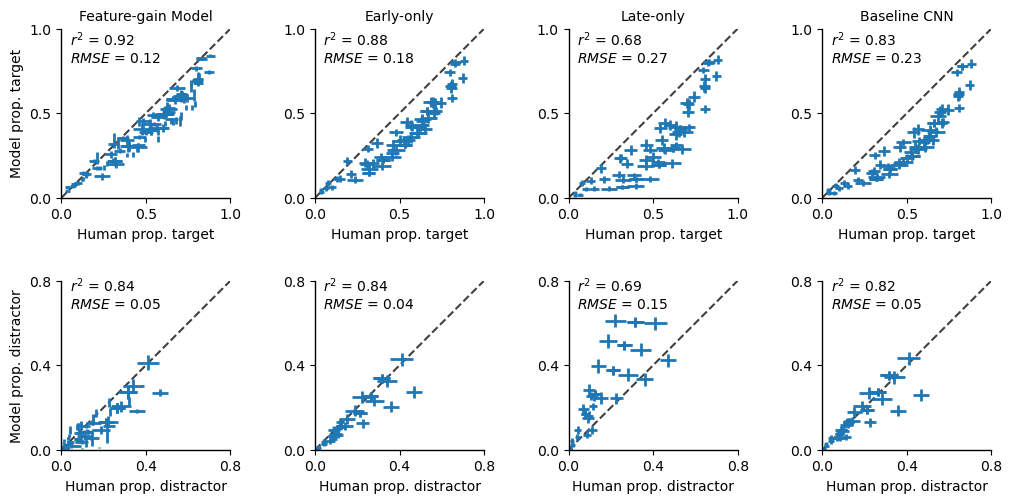

In [25]:
combined_results['snr_condition_str'] = combined_results['snr'].astype(str) + ' dB ' + combined_results['background_condition']
human_results = combined_results[combined_results.group.str.contains('Human')]
human_results = human_results.sort_values(['snr', 'background_condition'])

model_list = [model for model in combined_results.group.unique() if 'Human' not in model]

model_acc_r = []
model_conf_r = []
model_acc_rmse = []
model_conf_rmse = []

x = y = np.linspace(0,1,5)
fontsize = 10
aspect = 3

sem_order = 2 # 2 for 95% CI, 1 for SEM

fig, axs = plt.subplots(2, len(model_list), 
                        figsize=((aspect * len(model_list)),
                        aspect*2))
acc_axs = axs[0,:]
conf_axs = axs[1,:]

line_width=2
# for ix, group in enumerate(to_plot.group.unique()):
# add dashed line to each subplot 
for i in range(2):
    for j in range(1 + len(model_list)):
        if j != len(model_list):
            axs[i,j].plot(x,y, ls='dashed', color='k', alpha=0.75)


vert_spacing = 0.1 
conf_max_y = 0.8

model_r2_dict = {}
model_rmse_dict = {}
for ix, model in enumerate(model_list):
    if model == 'Feature-gain Model':
        fba_to_plot = combined_results[combined_results.group.str.contains('Feature')].groupby(['snr', 'background_condition']).agg({'accuracy': ['mean', 'sem'], 'confusions':['mean', 'sem']}).reset_index()
        fba_to_plot.columns = ['snr', 'background_condition', 'accuracy', 'acc_sem', 'confusions', 'conf_sem']
        fba_to_plot['snr_condition_str'] = fba_to_plot['snr'].astype(str) + ' dB ' + fba_to_plot['background_condition']

        fba_to_plot['group'] = 'Feature-gain model'
        model_results = fba_to_plot.sort_values(['snr', 'background_condition'])
    else:
        model_results = combined_results[combined_results.group == model]
        model_results = model_results.sort_values(['snr', 'background_condition'])

    # get missing snr x background conditions 
    model_conds = model_results.snr_condition_str.unique()
    human_conds = human_results.snr_condition_str.unique()
    conds_to_keep = human_conds[np.isin(human_conds, model_conds)]

    human_to_plot = human_results[human_results.snr_condition_str.isin(conds_to_keep)].copy()
    model_to_plot = model_results[model_results.snr_condition_str.isin(conds_to_keep)].copy()
    

    acc_axs[ix].errorbar(x=human_to_plot.accuracy, y=model_to_plot.accuracy,
                          xerr=human_to_plot.acc_sem * sem_order,
                         yerr=model_to_plot.acc_sem * sem_order, 
                         marker='',
                linestyle='', ms=3, elinewidth=line_width,)
    
    conf_axs[ix].errorbar(x=human_to_plot.confusions, y=model_to_plot.confusions,
                          xerr=human_to_plot.conf_sem * sem_order,
                          yerr=model_to_plot.conf_sem * sem_order,
                            marker='',
                linestyle='', ms=3, elinewidth=line_width,)
    
    acc_axs[ix].set_title(model, fontsize=fontsize)
    acc_axs[ix].set_xlabel(f"Human prop. target", fontsize=fontsize)
    conf_axs[ix].set_xlabel(f"Human prop. distractor", fontsize=fontsize)

    ## Add stats 
    r, p = stats.pearsonr(human_to_plot.accuracy,  model_to_plot.accuracy)
    # spearman_brown_r = r / np.sqrt(main_model_rho_acc)
    acc_axs[ix].annotate(f"$r^2$ = {r**2:.2f}", (0.05, 0.9), fontsize=fontsize)

    # add to dict 
    model_r2_dict[model] = {}
    model_rmse_dict[model] = {}

    samp_rmse = np.sqrt(np.mean((human_to_plot.accuracy.values - model_to_plot.accuracy.values)**2))
    acc_axs[ix].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.05, 0.8), fontsize=fontsize)
    model_r2_dict[model]['accuracy'] = r**2
    model_rmse_dict[model]['accuracy'] = samp_rmse

    # conf errors
    r, p = stats.pearsonr(human_to_plot.confusions, model_to_plot.confusions)
    conf_axs[ix].annotate(f"$r^2$ = {r**2:.2f}", (0.04, 0.75), fontsize=fontsize) 
    samp_rmse = np.sqrt(np.mean((human_to_plot.confusions.values - model_to_plot.confusions.values)**2))

    conf_rmse_y = 0.75 - (vert_spacing * conf_max_y)
    conf_axs[ix].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.04, conf_rmse_y), fontsize=fontsize) # old xy coords (0.25, 0.025)
    model_r2_dict[model]['confusions'] = r**2
    model_rmse_dict[model]['confusions'] = samp_rmse
    

    # set first row x and y limits to 0 1
ticks = np.linspace(0,1,3).round(1)

for ax in acc_axs.flat:
    ax.set_xticks(ticks=ticks) # set new labels
    ax.set_xticklabels(labels=ticks,fontsize=fontsize) 
    ax.set_yticks(ticks=ticks) # set new labels
    ax.set_yticklabels(labels= ticks, fontsize=fontsize)
    ax.set_ylim(0,1)
    ax.set_xlim(0,1)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1)
        ax.spines[axis].set_color('k')

ticks = np.linspace(0,.8,3).round(1)

for ax in conf_axs.flat:
    ax.set_xticks(ticks=ticks) # set new labels
    ax.set_xticklabels(labels=ticks,fontsize=fontsize) 
    ax.set_yticks(ticks=ticks) # set new labels
    ax.set_yticklabels(labels= ticks, fontsize=fontsize)
    ax.set_ylim(0,.8)
    ax.set_xlim(0,.8)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1)
        ax.spines[axis].set_color('k')

acc_axs[0].set_ylabel(f"Model prop. target", fontsize=fontsize)
conf_axs[0].set_ylabel(f"Model prop. distractor", fontsize=fontsize)

sns.despine()
# lines_labels = [ax.get_legend_handles_labels() for ax in [acc_axs[0]]]
# lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
plt.subplots_adjust(wspace=0.5)


for ax in axs.flat:
    ax.set(aspect='equal')

### Plot each feature-gain arch separately 

In [13]:
model_list

['word_task_v10_4MGB_ln_first_arch_1',
 'word_task_v10_4MGB_ln_first_arch_10',
 'word_task_v10_4MGB_ln_first_arch_12',
 'word_task_v10_4MGB_ln_first_arch_2',
 'word_task_v10_4MGB_ln_first_arch_4',
 'word_task_v10_4MGB_ln_first_arch_6',
 'word_task_v10_4MGB_ln_first_arch_7',
 'word_task_v10_4MGB_ln_first_arch_8',
 'word_task_v10_4MGB_ln_first_arch_9',
 'word_task_v10_main_feature_gain_config',
 'Early-only',
 'Late-only',
 'Baseline CNN']

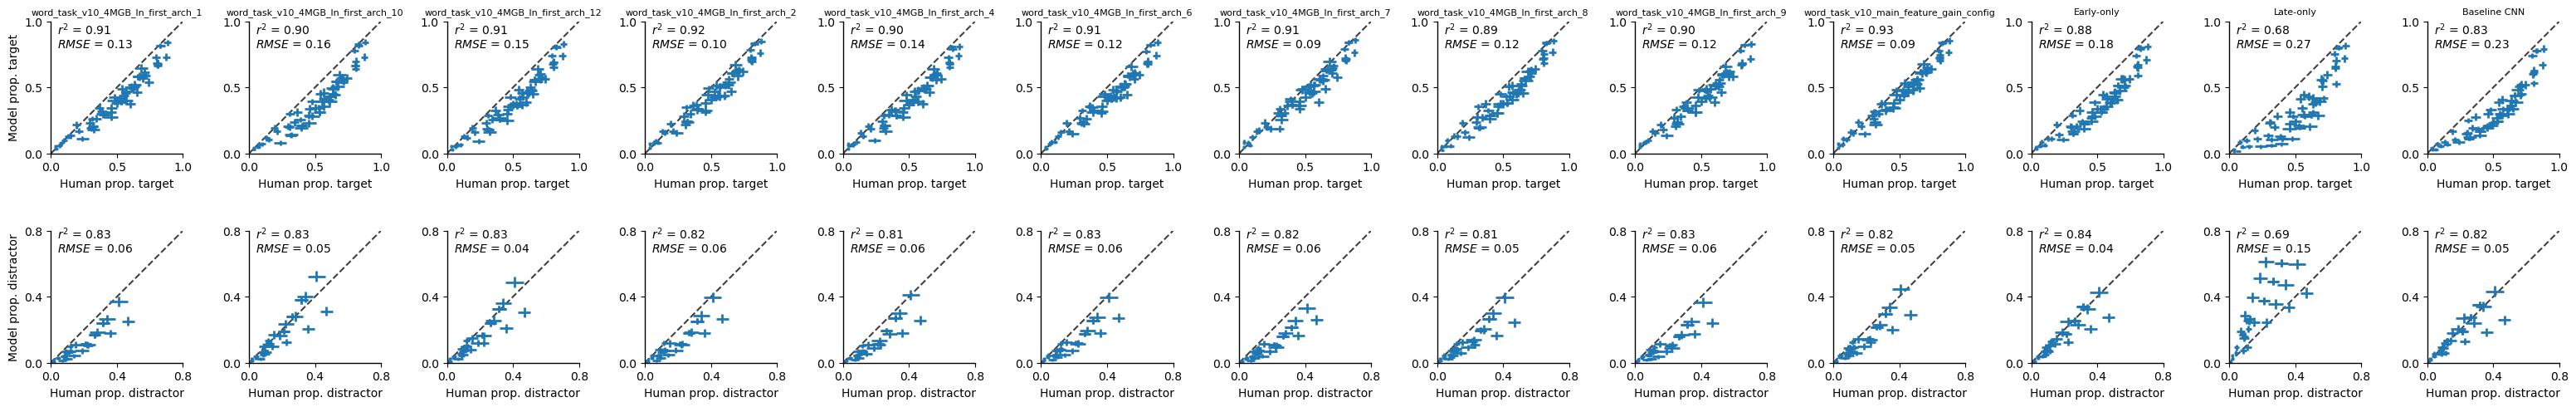

In [21]:
combined_results['snr_condition_str'] = combined_results['snr'].astype(str) + ' dB ' + combined_results['background_condition']
human_results = combined_results[combined_results.group.str.contains('Human')]
human_results = human_results.sort_values(['snr', 'background_condition'])

model_list = [model for model in combined_results.model.unique() if 'Human' not in model]

model_acc_r = []
model_conf_r = []
model_acc_rmse = []
model_conf_rmse = []

x = y = np.linspace(0,1,5)
fontsize = 10
aspect = 3

sem_order = 2 # 2 for 95% CI, 1 for SEM

fig, axs = plt.subplots(2, len(model_list), 
                        figsize=((aspect * len(model_list)),
                        aspect*2))
acc_axs = axs[0,:]
conf_axs = axs[1,:]

line_width=2
# for ix, group in enumerate(to_plot.group.unique()):
# add dashed line to each subplot 
for i in range(2):
    for j in range(1 + len(model_list)):
        if j != len(model_list):
            axs[i,j].plot(x,y, ls='dashed', color='k', alpha=0.75)


vert_spacing = 0.1 
conf_max_y = 0.8

model_r2_dict = {}
model_rmse_dict = {}
for ix, model in enumerate(model_list):

    model_results = combined_results[combined_results.model == model]
    model_results = model_results.sort_values(['snr', 'background_condition'])

    # get missing snr x background conditions 
    model_conds = model_results.snr_condition_str.unique()
    human_conds = human_results.snr_condition_str.unique()
    conds_to_keep = human_conds[np.isin(human_conds, model_conds)]

    human_to_plot = human_results[human_results.snr_condition_str.isin(conds_to_keep)].copy()
    model_to_plot = model_results[model_results.snr_condition_str.isin(conds_to_keep)].copy()
    

    acc_axs[ix].errorbar(x=human_to_plot.accuracy, y=model_to_plot.accuracy,
                          xerr=human_to_plot.acc_sem * sem_order,
                         yerr=model_to_plot.acc_sem * sem_order, 
                         marker='',
                linestyle='', ms=3, elinewidth=line_width,)
    
    conf_axs[ix].errorbar(x=human_to_plot.confusions, y=model_to_plot.confusions,
                          xerr=human_to_plot.conf_sem * sem_order,
                          yerr=model_to_plot.conf_sem * sem_order,
                            marker='',
                linestyle='', ms=3, elinewidth=line_width,)
    
    acc_axs[ix].set_title(model, fontsize=fontsize-2)
    acc_axs[ix].set_xlabel(f"Human prop. target", fontsize=fontsize)
    conf_axs[ix].set_xlabel(f"Human prop. distractor", fontsize=fontsize)

    ## Add stats 
    r, p = stats.pearsonr(human_to_plot.accuracy,  model_to_plot.accuracy)
    # spearman_brown_r = r / np.sqrt(main_model_rho_acc)
    acc_axs[ix].annotate(f"$r^2$ = {r**2:.2f}", (0.05, 0.9), fontsize=fontsize)

    # add to dict 
    model_r2_dict[model] = {}
    model_rmse_dict[model] = {}

    samp_rmse = np.sqrt(np.mean((human_to_plot.accuracy.values - model_to_plot.accuracy.values)**2))
    acc_axs[ix].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.05, 0.8), fontsize=fontsize)
    model_r2_dict[model]['accuracy'] = r**2
    model_rmse_dict[model]['accuracy'] = samp_rmse

    # conf errors
    r, p = stats.pearsonr(human_to_plot.confusions, model_to_plot.confusions)
    conf_axs[ix].annotate(f"$r^2$ = {r**2:.2f}", (0.04, 0.75), fontsize=fontsize) 
    samp_rmse = np.sqrt(np.mean((human_to_plot.confusions.values - model_to_plot.confusions.values)**2))

    conf_rmse_y = 0.75 - (vert_spacing * conf_max_y)
    conf_axs[ix].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.04, conf_rmse_y), fontsize=fontsize) # old xy coords (0.25, 0.025)
    model_r2_dict[model]['confusions'] = r**2
    model_rmse_dict[model]['confusions'] = samp_rmse
    

    # set first row x and y limits to 0 1
ticks = np.linspace(0,1,3).round(1)

for ax in acc_axs.flat:
    ax.set_xticks(ticks=ticks) # set new labels
    ax.set_xticklabels(labels=ticks,fontsize=fontsize) 
    ax.set_yticks(ticks=ticks) # set new labels
    ax.set_yticklabels(labels= ticks, fontsize=fontsize)
    ax.set_ylim(0,1)
    ax.set_xlim(0,1)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1)
        ax.spines[axis].set_color('k')

ticks = np.linspace(0,.8,3).round(1)

for ax in conf_axs.flat:
    ax.set_xticks(ticks=ticks) # set new labels
    ax.set_xticklabels(labels=ticks,fontsize=fontsize) 
    ax.set_yticks(ticks=ticks) # set new labels
    ax.set_yticklabels(labels= ticks, fontsize=fontsize)
    ax.set_ylim(0,.8)
    ax.set_xlim(0,.8)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1)
        ax.spines[axis].set_color('k')

acc_axs[0].set_ylabel(f"Model prop. target", fontsize=fontsize)
conf_axs[0].set_ylabel(f"Model prop. distractor", fontsize=fontsize)

sns.despine()
# lines_labels = [ax.get_legend_handles_labels() for ax in [acc_axs[0]]]
# lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
plt.subplots_adjust(wspace=0.5)


for ax in axs.flat:
    ax.set(aspect='equal')

## Plot aggrigate summary 

## Plot bar chart, pooling accuracy and confusions

In [30]:
pd.melt(human_results, id_vars=['snr', 'background_condition', 'group'], value_vars=['accuracy', 'confusions'], var_name='metric', value_name='measure')

,snr,background_condition,group,metric,measure
0,-9,0 azim delta 0 elev delta,Human (N=33),accuracy,0.123106
1,-9,0 azim delta 10 elev delta,Human (N=33),accuracy,0.129924
2,-9,0 azim delta 60 elev delta,Human (N=33),accuracy,0.147727
3,-9,1-talker,Human (N=195),accuracy,0.317094
4,-9,10 azim delta 0 elev delta,Human (N=33),accuracy,0.212121
...,...,...,...,...,...
195,6,0 azim delta 10 elev delta,Human (N=33),confusions,0.011364
196,6,0 azim delta 60 elev delta,Human (N=33),confusions,0.013258
197,6,10 azim delta 0 elev delta,Human (N=33),confusions,0.011364
198,6,60 azim delta 0 elev delta,Human (N=33),confusions,0.013258


In [148]:
## Get model measures per group 

combined_results['snr_condition_str'] = combined_results['snr'].astype(str) + ' dB ' + combined_results['background_condition']
human_results = combined_results[combined_results.group.str.contains('Human')]
human_results = human_results.sort_values(['snr', 'background_condition'])

melted_human_results = pd.melt(human_results, id_vars=['snr', 'background_condition'], value_vars=['accuracy', 'confusions'], var_name='metric', value_name='measure')
melted_human_results = melted_human_results.sort_values(['snr', 'background_condition',  'metric'])

model_list = [model for model in combined_results.group.unique() if 'Human' not in model]

melted_human_results['condition_string'] = melted_human_results['snr'].astype(str) + ' dB ' + melted_human_results['background_condition'] + ' ' + melted_human_results['metric']

unique_conds = melted_human_results.condition_string.unique()
n_to_sample = len(melted_human_results)
model_agg_sim_records = []

n_boots = 1000

for ix, model in enumerate(model_list):
    if model == 'Feature-gain Model':
        fba_to_plot = combined_results[combined_results.group.str.contains('Feature')].groupby(['snr', 'background_condition']).agg({'accuracy': ['mean', 'sem'], 'confusions':['mean', 'sem']}).reset_index()
        fba_to_plot.columns = ['snr', 'background_condition', 'accuracy', 'acc_sem', 'confusions', 'conf_sem']
        fba_to_plot['snr_condition_str'] = fba_to_plot['snr'].astype(str) + ' dB ' + fba_to_plot['background_condition']

        fba_to_plot['group'] = 'Feature-gain model'
        model_results = fba_to_plot.sort_values(['snr', 'background_condition'])
    else:
        model_results = combined_results[combined_results.model == model]
        model_results = model_results.sort_values(['snr', 'background_condition'])
    model_melted = pd.melt(model_results, id_vars=['snr', 'background_condition', 'group'], value_vars=['accuracy', 'confusions'], var_name='metric', value_name='measure')
    model_melted = model_melted.sort_values(['snr', 'background_condition', 'group',  'metric'])

    model_melted['condition_string'] = model_melted['snr'].astype(str) + ' dB ' + model_melted['background_condition'] + ' ' + model_melted['metric']
    ## Add stats 
    r, p = stats.pearsonr(melted_human_results.measure,  model_melted.measure)
    # spearman_brown_r = r / np.sqrt(main_model_rho_acc)
    acc_r = r ** 2 
    # add to dict 
    acc_rmse = np.sqrt(np.mean((melted_human_results.measure.values - model_melted.measure.values)**2))

    # get error via bootstrap 
    acc_r_boots = []
    acc_rmse_boots = []
    for _ in range(n_boots):
        conditions_to_sample = np.random.choice(unique_conds, size=len(unique_conds), replace=True)
        # bootstrap sample 
        human_sample = melted_human_results[melted_human_results.condition_string.isin(conditions_to_sample)].sample(n=n_to_sample, replace=True)
        human_sample = human_sample.sort_values(['snr', 'background_condition', 'metric'])
        model_sample = model_melted[model_melted.condition_string.isin(conditions_to_sample)].sample(n=n_to_sample, replace=True)
        model_sample = model_sample.sort_values(['snr', 'background_condition', 'metric'])

        # get r
        r, p = stats.pearsonr(human_sample.measure,  model_sample.measure)
        acc_r_boot = r ** 2 
        acc_r_boots.append(acc_r_boot)

        # get rmse
        acc_rmse_boot = np.sqrt(np.mean((human_sample.measure.values - model_sample.measure.values)**2))
        acc_rmse_boots.append(acc_rmse_boot)
    
    # get 95% CI
    acc_r_ci = np.percentile(acc_r_boots, [2.5, 97.5])
    acc_rmse_ci = np.percentile(acc_rmse_boots, [2.5, 97.5])
    # add to dict

    record = {'group': model, 'acc_r': acc_r, 'acc_r_ci':acc_r_ci ,'acc_rmse': acc_rmse, 'acc_rmse_ci': acc_rmse_ci}
    model_agg_sim_records.append(record)
model_agg_sim_df = pd.DataFrame.from_records(model_agg_sim_records)

In [149]:
model_agg_sim_df

,group,acc_r,acc_r_ci,acc_rmse,acc_rmse_ci
0,Feature-gain Model,0.958406,"[2.570189559463946e-05, 0.07509864044227817]",0.091485,"[0.30997002413676944, 0.38839810016622156]"
1,Early-only,0.912392,"[1.2453447414859262e-05, 0.07693348073811547]",0.133591,"[0.29726492792553927, 0.3746330009272209]"
2,Late-only,0.435354,"[1.242468437503112e-05, 0.06774672551392778]",0.219196,"[0.29479288848370155, 0.3660128316164688]"
3,Baseline CNN,0.853175,"[7.172027687511754e-05, 0.0821797649009059]",0.164239,"[0.29695044459979025, 0.3736208363734606]"


In [135]:
melted_human_results[melted_human_results.condition_string.isin(conditions_to_sample)]

,snr,background_condition,metric,measure,condition_string
2,-9,0 azim delta 60 elev delta,accuracy,0.147727,-9 dB 0 azim delta 60 elev delta
102,-9,0 azim delta 60 elev delta,confusions,0.264405,-9 dB 0 azim delta 60 elev delta
3,-9,1-talker,accuracy,0.317094,-9 dB 1-talker
103,-9,1-talker,confusions,0.315385,-9 dB 1-talker
4,-9,10 azim delta 0 elev delta,accuracy,0.212121,-9 dB 10 azim delta 0 elev delta
...,...,...,...,...,...
195,6,0 azim delta 10 elev delta,confusions,0.011364,6 dB 0 azim delta 10 elev delta
96,6,0 azim delta 60 elev delta,accuracy,0.790152,6 dB 0 azim delta 60 elev delta
196,6,0 azim delta 60 elev delta,confusions,0.013258,6 dB 0 azim delta 60 elev delta
98,6,60 azim delta 0 elev delta,accuracy,0.813017,6 dB 60 azim delta 0 elev delta


In [124]:
len(set(model_sample.condition_string.values).intersection(set(human_sample.condition_string.values))), human_sample.condition_string.nunique() 

(63, 66)

In [88]:
model_agg_sim_df

,group,acc_r,acc_r_ci,acc_rmse,acc_rmse_ci
0,Feature-gain Model,0.958406,"[3.6506446285829793e-06, 0.025357694245965574]",0.091485,"[0.3354695481160639, 0.40240036680758406]"
1,Early-only,0.912392,"[3.872425920541306e-06, 0.027494417595468734]",0.133591,"[0.319181689157179, 0.38345572200736333]"
2,Late-only,0.435354,"[4.105107634701609e-06, 0.026266761841118594]",0.219196,"[0.30963466869433054, 0.3729022085803728]"
3,Baseline CNN,0.853175,"[4.36350575682401e-06, 0.026029676148201918]",0.164239,"[0.31936174538989887, 0.3813561730093639]"


/tmp/ipykernel_2577014/1679756926.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(data=model_agg_sim_df, x='group', y='acc_r', palette='Set2')


Text(0, 0.5, "Pearson's $r^2$")

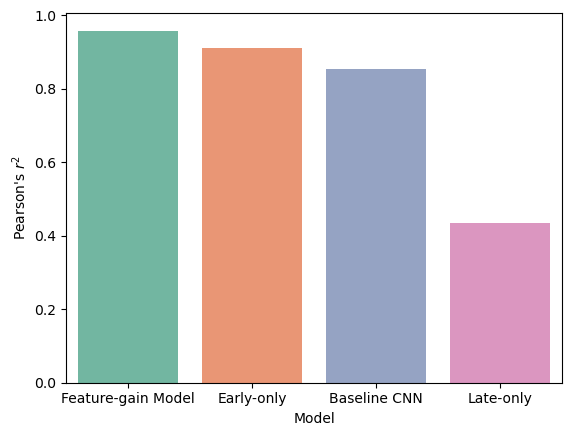

In [ ]:
model_agg_sim_df = model_agg_sim_df.sort_values('acc_r', ascending=False)

g = sns.barplot(data=model_agg_sim_df, x='group', y='acc_r', palette='Set2')
g.set_xlabel('Model')
g.set_ylabel("Pearson\'s $r^2$")

/tmp/ipykernel_2832227/3101557016.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, horizontalalignment='right')
/tmp/ipykernel_2832227/3101557016.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, horizontalalignment='right')


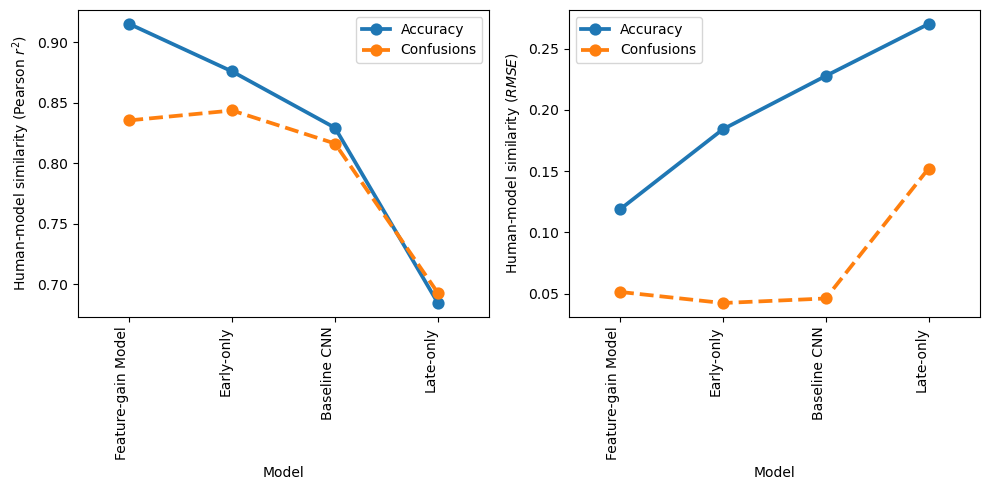

In [15]:
## Make double bar chart of r and RMSE
r_df = pd.DataFrame(model_r2_dict).T
rmse_df = pd.DataFrame(model_rmse_dict).T

fig, axs = plt.subplots(1,2, figsize=(10,5))

# x order is index sorted by r_df.accuracy 
order = r_df.accuracy.sort_values(ascending=False).index
r_df = r_df.loc[order]
# x_order = r_df.index

rmse_order = rmse_df.accuracy.sort_values(ascending=True).index
rmse_df = rmse_df.loc[rmse_order]



sns.pointplot(data=r_df, x=r_df.index, y=r_df.accuracy, ax=axs[0], linestyles='-', label='Accuracy')
sns.pointplot(data=r_df, x=r_df.index, y=r_df.confusions, ax=axs[0], linestyles='--', label='Confusions')

sns.pointplot(data=rmse_df, x=rmse_df.index, y=rmse_df.accuracy, ax=axs[1], linestyles='-', label='Accuracy')
sns.pointplot(data=rmse_df, x=rmse_df.index, y=rmse_df.confusions, ax=axs[1], linestyles='--', label='Confusions')

for ax in axs:
    # ax.set_ylim(0,1)
    ax.set_xlabel('Model')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, horizontalalignment='right')

axs[0].set_ylabel("Human-model similarity (Pearson $r^2$)")
axs[1].set_ylabel('Human-model similarity ($RMSE$)')
# axs[0].set_title('Task-Accuracy')
# axs[0].set_title('Task-Confusions')
plt.tight_layout()
